In [162]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [146]:
X,y = make_classification(
    n_samples=200,
    n_features=4,
    n_classes=2,
    random_state=42
)

In [147]:
X = np.transpose(X)

In [148]:
dictionary = {
    "f1": X[0],
    "f2": X[1],
    "f3": X[2],
    "f4": X[3],
    "target": y
}

In [149]:
df = pd.DataFrame(dictionary)

In [150]:
df.head()

,f1,f2,f3,f4,target
0,1.689767,-1.408241,-0.962936,1.163491,1
1,0.855820,-0.430646,-0.390659,0.435911,1
2,-1.175042,-1.447633,-0.163790,0.508040,0
3,1.394775,2.019333,0.297780,-0.766396,1
4,-0.073240,0.336417,0.136302,-0.199882,1


In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      200 non-null    float64
 1   f2      200 non-null    float64
 2   f3      200 non-null    float64
 3   f4      200 non-null    float64
 4   target  200 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [152]:
df.describe()

,f1,f2,f3,f4,target
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-0.008239,0.075489,0.028260,-0.042915,0.500000
std,1.303288,1.367159,0.571124,0.777588,0.501255
min,-3.365582,-3.085661,-1.157399,-2.743229,0.000000
25%,-0.949105,-0.972878,-0.410679,-0.593736,0.000000
50%,0.023073,0.284271,0.046618,-0.109464,0.500000
75%,1.036479,0.969559,0.444390,0.548233,1.000000
max,2.917252,3.971278,2.069709,1.643544,1.000000


In [153]:
X_train, X_test, y_train,y_test = train_test_split(df[["f1","f2","f3","f4"]], df["target"], test_size=0.2, random_state=42)

In [154]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    # criterion = "gini",
    max_depth=3,
)

In [155]:
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [156]:
y_pred = decision_tree.predict(X_test)

In [157]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [158]:
print("Accuracy:",round(accuracy,2))
print("Precision:",round(precision,2))
print("Recall:",round(recall,2))
print("F1:",round(f1,2))


Accuracy: 0.92
Precision: 0.94
Recall: 0.89
F1: 0.92


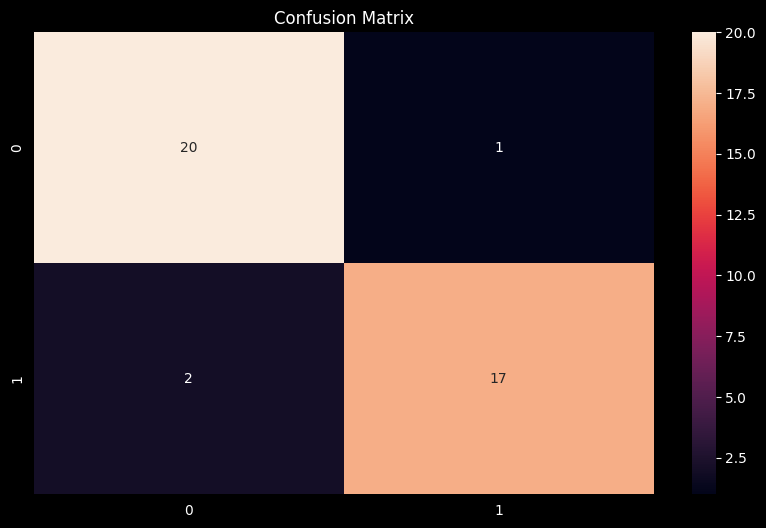

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True , fmt="d")


In [160]:
from sklearn.tree import plot_tree

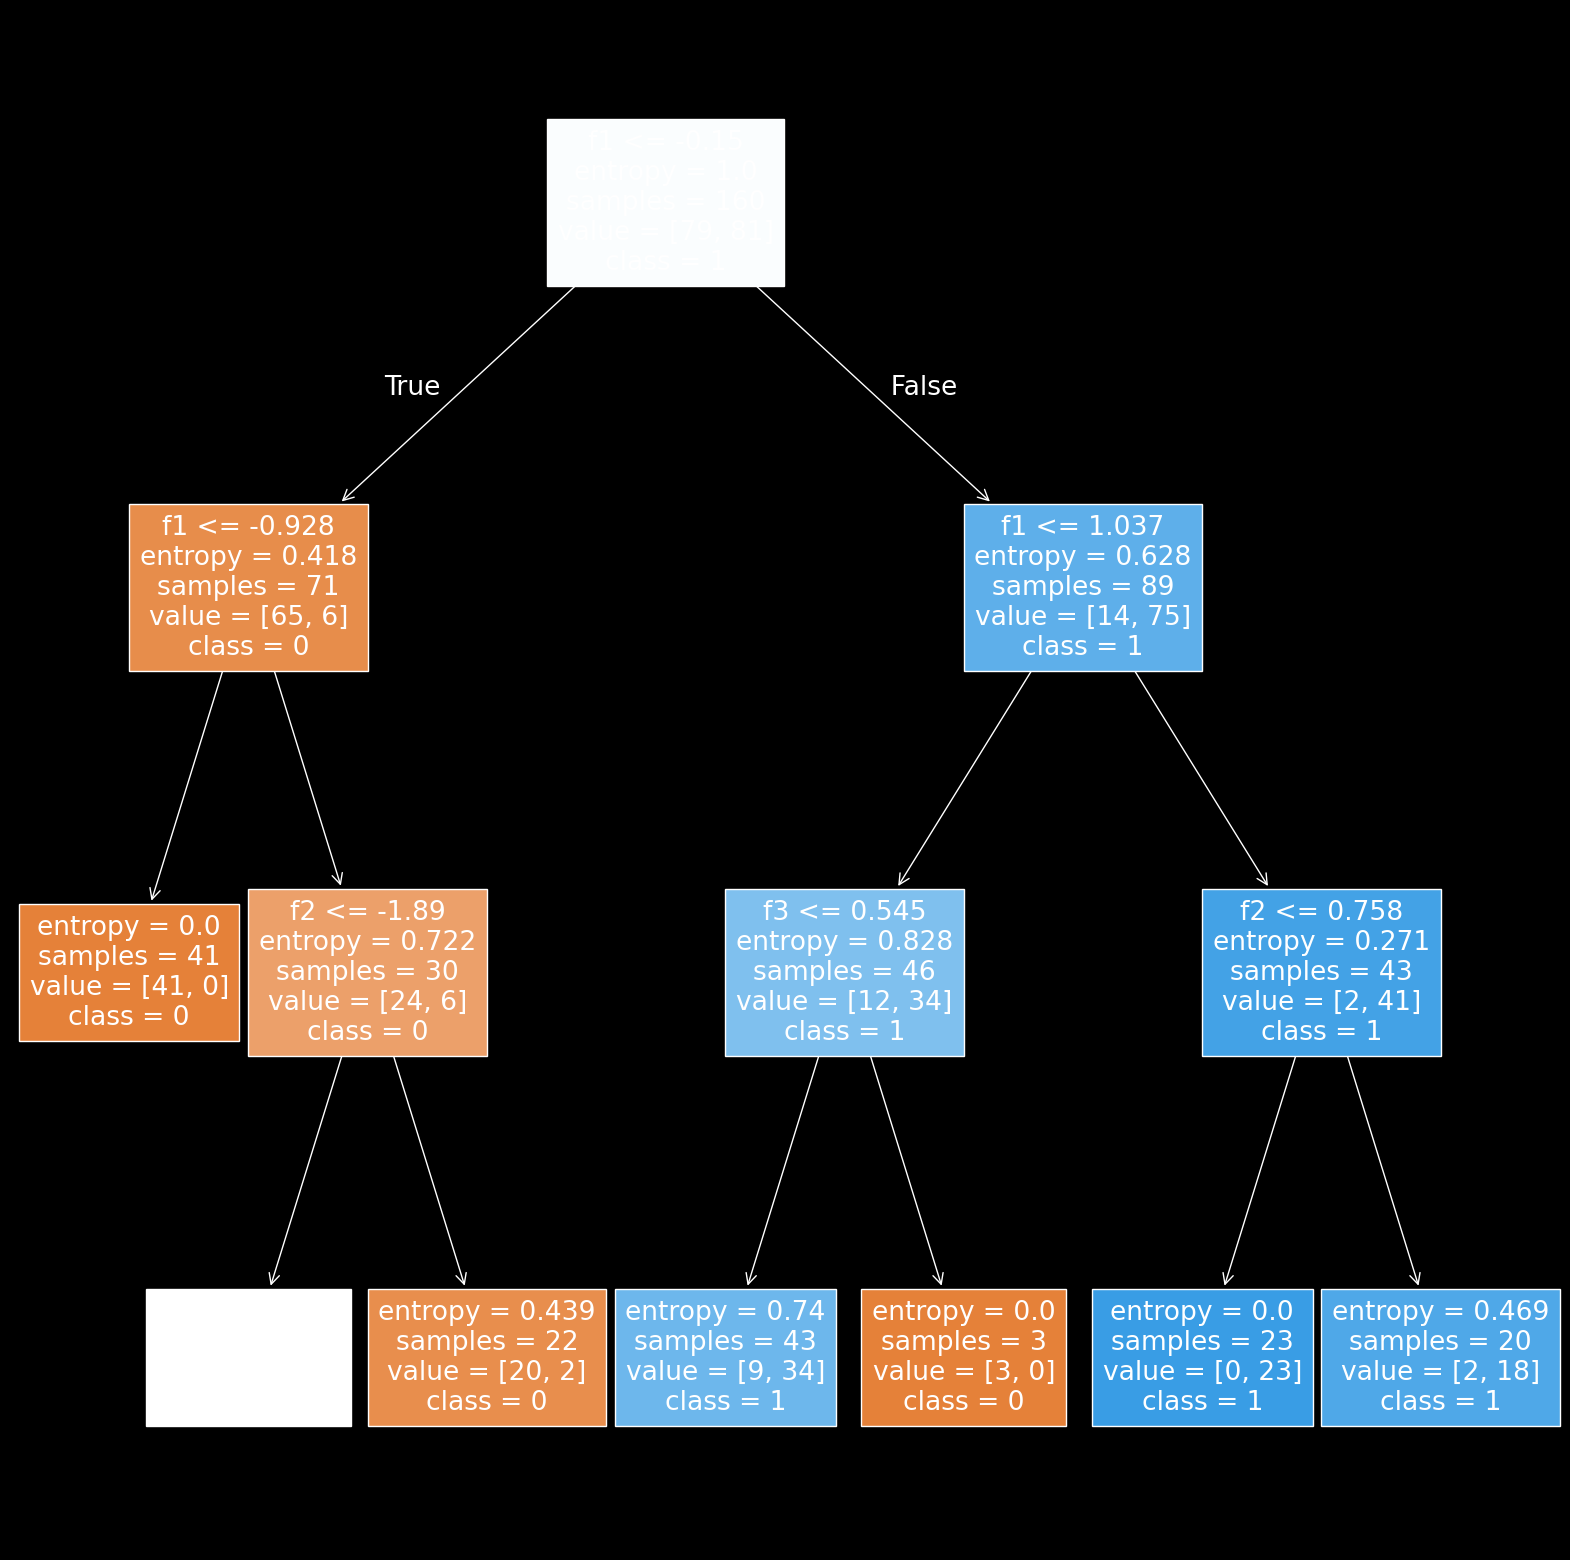

In [161]:
plt.figure(figsize=(20,20))
plot_tree(
    decision_tree ,
          feature_names=["f1","f2","f3","f4"] ,
          class_names=["0" , "1"] ,
          filled=True
          )